In [1]:
import sys
sys.path.insert(0, '../../')

from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import RidgeCV, Ridge

from panel_exp.panel_data import long_df_to_paneldataset, PanelDataset, TimePeriod
from panel_exp.methods.scm import SyntheticControl, AugSynth 
from panel_exp.methods.tbr import TBR, TBRRidge

from panel_exp.inference.unit_jackknife import unit_jk, unit_jackknife, time_jackknife_plus
from panel_exp.inference import conformal
from panel_exp.inference.k_fold import kfold, cross_fold
from panel_exp.impact import ImpactAnalyzer
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt


In [2]:
from __future__ import annotations
import numpy as np
import pandas as pd
import scipy.stats as st
from dataclasses import dataclass

from matplotlib import pyplot as plt
from typing import Dict, Optional
from abc import (
    ABC,
    abstractmethod,
    ) 

from scipy.optimize import minimize
from sklearn.linear_model import RidgeCV, Ridge
import warnings

import cvxpy as cp

In [3]:

class SyntheticControl(ImpactAnalyzer):
    """
    Implements the Synthetic Control Method (SCM) for causal inference.
    """

    def __init__(
        self,
        inference: Optional[Callable] = None,
        penalty: str = "l2",
        treatment_aggregation_fun: Optional[str] = None,
        control_aggregation_fun: Optional[str] = None,
        penalty_strength: float = 0.01,
        alpha: float = 0.1,
        full_model = False
    ):
        """
        Args:
            inference: the inference method to use, if any
            penalty: the penalty to use for the optimization problem
            penalty_strength: the strength of the penalty to use
        """
        self.penalty = penalty
        self.penalty_strength = penalty_strength
        self.inference = inference
        self.alpha = alpha
        self.full_model = full_model
        self.treatment_aggregation_fun = treatment_aggregation_fun
        self.control_aggregation_fun = control_aggregation_fun


    def fit_data(self, panel_data):
        # no need to change anything from panel dataset
        self.panel_data = panel_data

    def fit_model(self):
        def balance_objective(x):
            x = x.reshape((control.shape[1], test.shape[0]))
            # minimize the sum of squared errors
            # subject to an entropy penalty
            imbalance = np.sum(np.square(test.T - control @ x))
            if self.penalty == "entropy":
                imbalance += self.penalty_strength * -np.sum(x * np.log(x))
            elif self.penalty == "l1":
                imbalance += self.penalty_strength * np.sum(np.abs(x))
            elif self.penalty == "l2":
                imbalance += self.penalty_strength * np.sum(np.square(x))
            else:
                raise NotImplemented(f"Unknown penalty {penalty}")
            return imbalance 

        if self.full_model:
            control, test = self.panel_data.split_control_test_units(
            self.panel_data.treated_units, period='full' )
        else:
            control, test = self.panel_data.split_control_test_units(treated_units = self.panel_data.treated_units)
 

        control = control.values.T
        test = test.values
        x0 = (np.ones((control.shape[1], test.shape[0])) / control.shape[1]).flatten()
        simplex_bounds = [(0, 1) for _ in range((control.shape[1] * test.shape[0]))]
        
        with warnings.catch_warnings():
            warnings.filterwarnings("ignore", category=RuntimeWarning)
            res = minimize(
                balance_objective,
                x0,
                tol = 1e-16 , 
                method="SLSQP",
                bounds=simplex_bounds,
                constraints={'type':'eq', 'fun': lambda x: np.sum(x.reshape(control.shape[1], test.shape[0]), axis=0) - 1} )

        self.weights = res.x

        class Model:
            def __init__(self, weights):
                self.weights = weights.reshape(control.shape[1], test.shape[0])
            def predict(self, x):
                return x @ self.weights

        model = Model(self.weights)

        return model


In [4]:
ls ../data/

google_sales.csv   meta_geo.csv       ps_up.csv
kansas_parsed.csv  ps_hu_exp.csv      smoking.csv


In [5]:
# kansas , smoking
ds = 'meta_geo'

if ds == 'kansas':
    long_df = pd.read_csv('../data/kansas_parsed.csv')
    pds = long_df_to_paneldataset(long_df, "year_qtr", "state", "lngdp", ["Kansas"], 2012)
    #pds = long_df_to_paneldataset(long_df, "year_qtr", "state", "lngdp", ["Kansas", "Illinois"], [2012, 2012])

if ds == 'smoking':
    long_df = pd.read_csv('../data/smoking.csv')
    long_df.columns = ['unnamed', 'unit', 'time_unit', 'y',  'lnincome','beer','age15to24','retprice']
    pds = long_df_to_paneldataset(long_df, "time_unit", "unit", "y", ["California" ], [1988 ]) 

if ds == 'meta_geo':
    long_df = pd.read_csv('../data/meta_geo.csv')
    wide_df = pd.pivot_table(long_df, index='location', columns='time', values='Y')
    pds = PanelDataset(wide_df, [TimePeriod(start =91, end=105), TimePeriod(start =91, end=105)], ["chicago", "portland"])
    #pds = PanelDataset(wide_df, [TimePeriod(start =91, end=105) ], ["portland" ])


# meta, geo


In [6]:
pds


        Panel Dataset Summary
        ---------------------
        Number of time points: 105
        Number of units: 40
        Number of treated units: 2
        Treated units: ['chicago', 'portland']
        Treated periods: [TimePeriod(start=91, end=105), TimePeriod(start=91, end=105)]
        

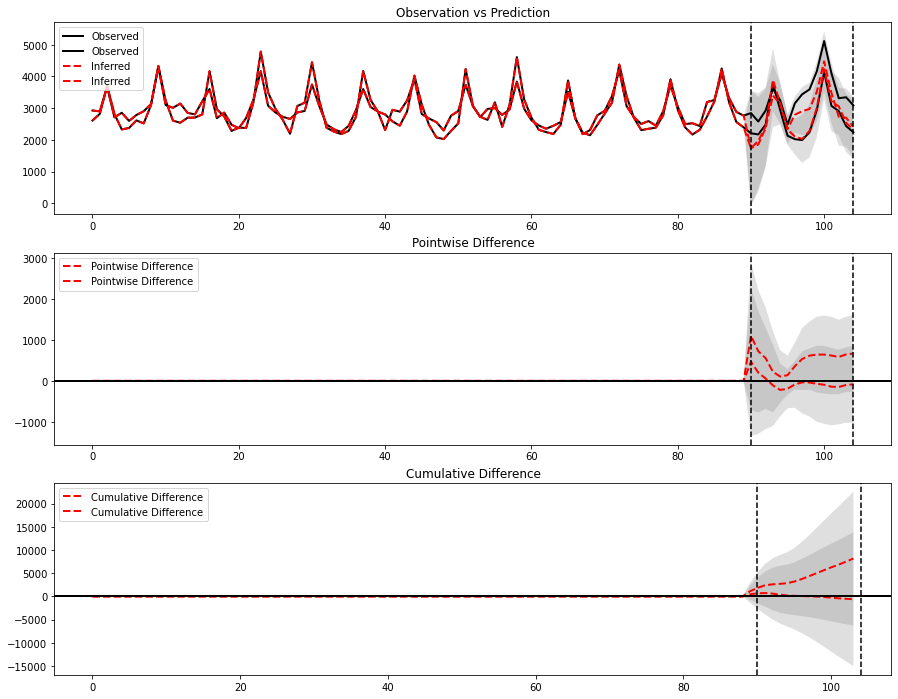

In [7]:
est = SyntheticControl(inference='Kfold')
est.run_analysis(pds)
est.plot()


<class 'panel_exp.methods.tbr.TBRRidge'>


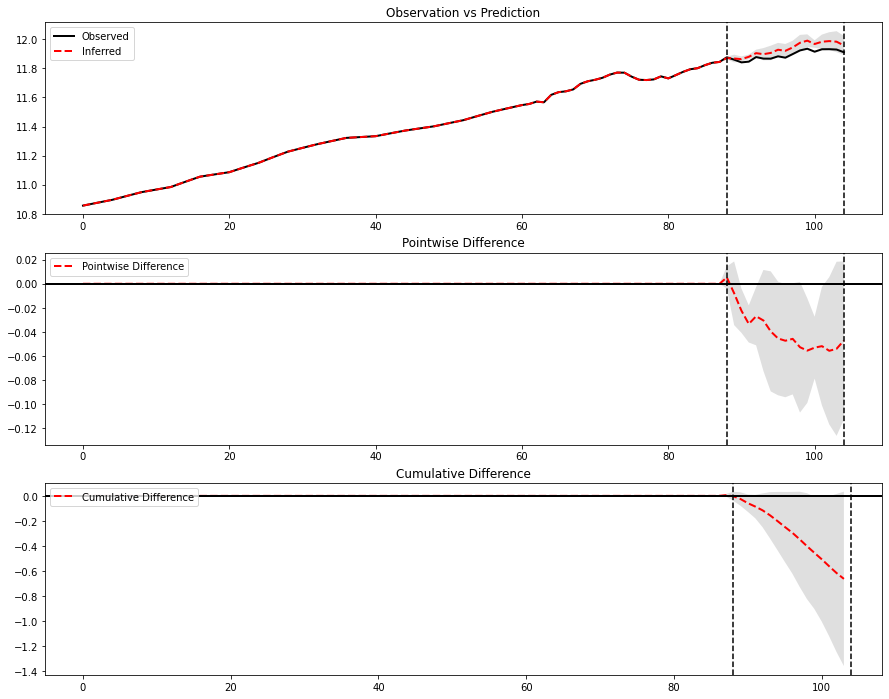

<class '__main__.SyntheticControl'>


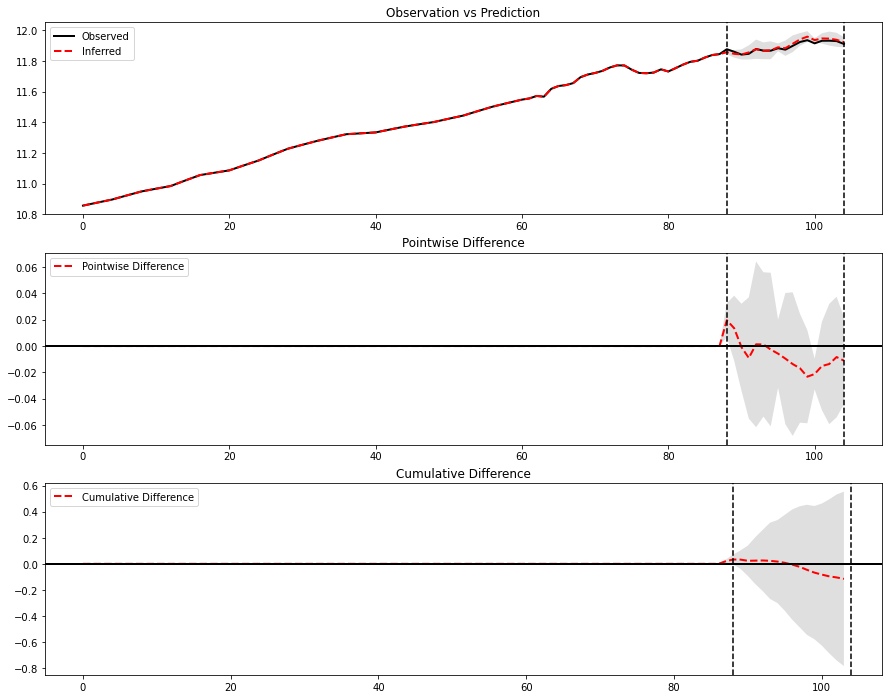

In [8]:
long_df = pd.read_csv('../data/kansas_parsed.csv')
pds = long_df_to_paneldataset(long_df, "year_qtr", "state", "lngdp", ["Kansas"], 2012)

for model in [TBRRidge, SyntheticControl]: #, AugSynth , TBRRidge]:
    print(str(model))
    est = model(inference='Kfold')
    est.run_analysis(pds)
    est.plot()

<class 'panel_exp.methods.tbr.TBRRidge'>


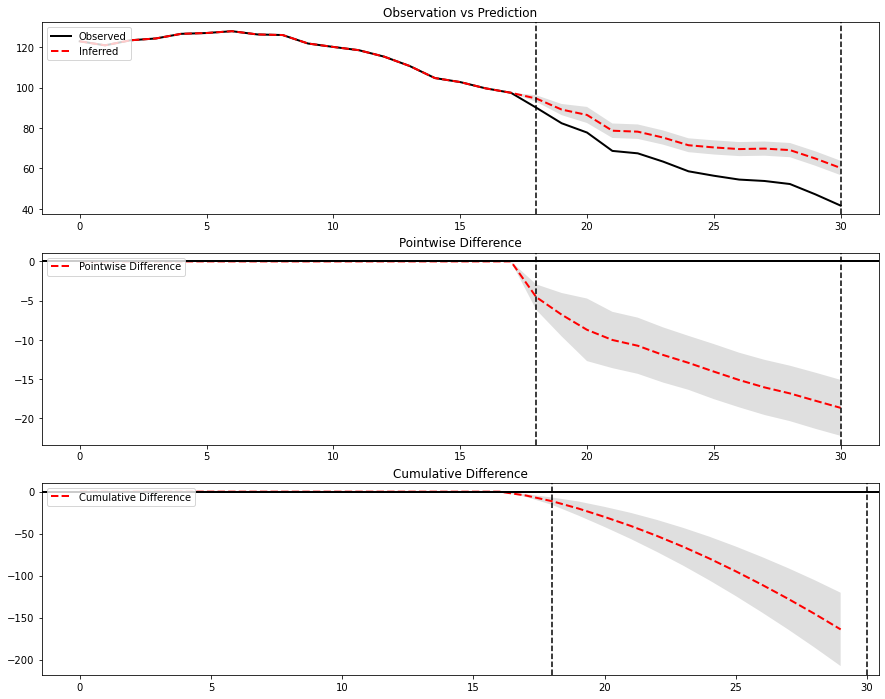

<class '__main__.SyntheticControl'>


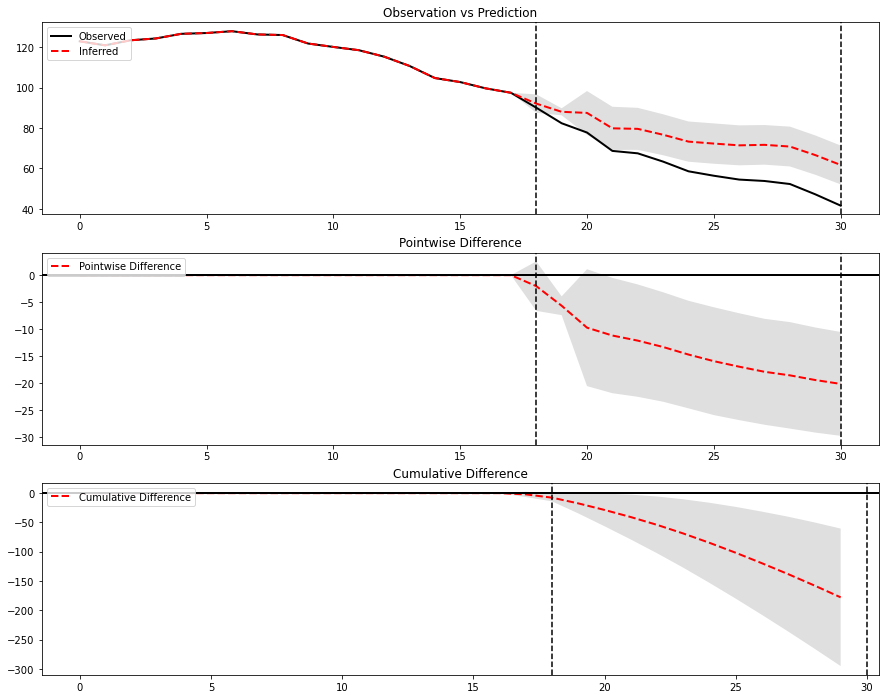

In [9]:
long_df = pd.read_csv('../data/smoking.csv')
long_df.columns = ['unnamed', 'unit', 'time_unit', 'y',  'lnincome','beer','age15to24','retprice']
pds = long_df_to_paneldataset(long_df, "time_unit", "unit", "y", ["California" ], [1988 ]) 

for model in [TBRRidge, SyntheticControl]: #, AugSynth , TBRRidge]:
    print(str(model))
    est = model(inference='Kfold')
    est.run_analysis(pds)
    est.plot()

<class 'panel_exp.methods.tbr.TBRRidge'>


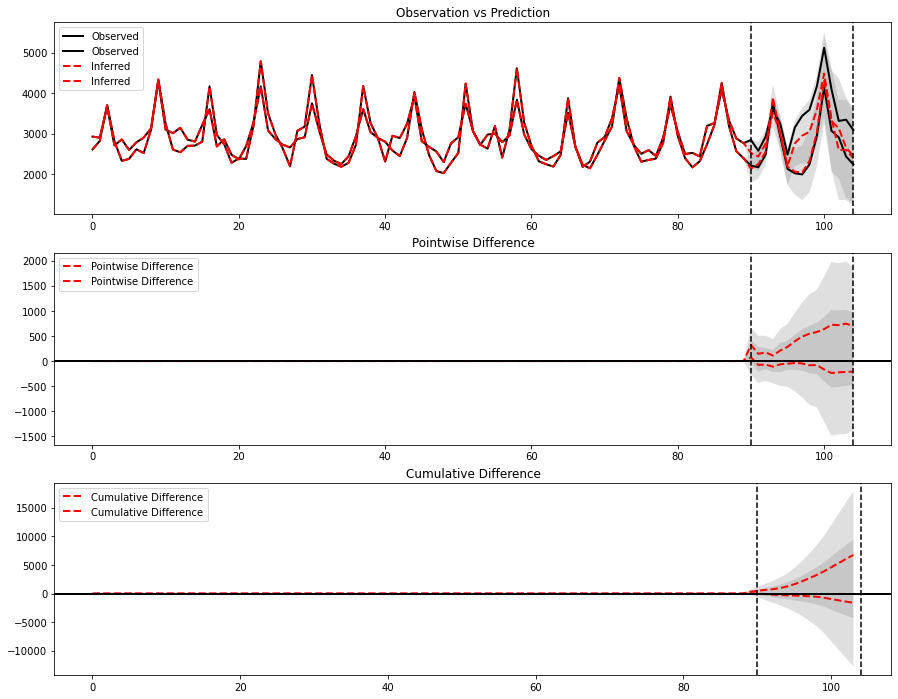

<class '__main__.SyntheticControl'>


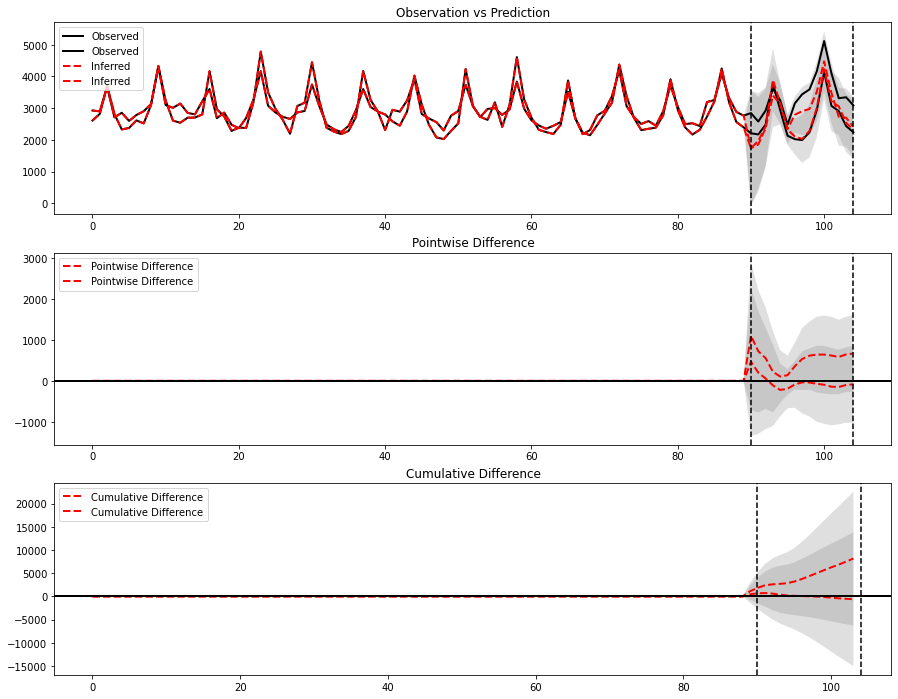

In [10]:
long_df = pd.read_csv('../data/meta_geo.csv')
wide_df = pd.pivot_table(long_df, index='location', columns='time', values='Y')
pds = PanelDataset(wide_df, [TimePeriod(start =91, end=105), TimePeriod(start =91, end=105)], ["chicago", "portland"])

for model in [TBRRidge, SyntheticControl]: #, AugSynth , TBRRidge]:
    print(str(model))
    est = model(inference='Kfold')
    est.run_analysis(pds)
    est.plot()